In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics roboflow -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.0 MB/s eta 0:00:00


In [14]:
# Xóa dataset cũ
!rm -rf /content/data/detection

# Download dataset mới
from roboflow import Roboflow
rf = Roboflow(api_key="0pT7PRN1B1WogPFVtBNc")
project = rf.workspace("sliit-kuemd").project("food-detection-3lhd1")
version = project.version(12)
dataset = version.download("yolov8", location="/content/data/detection")

print("✅ Done!")
!cat /content/data/detection/data.yaml

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/data/detection in yolov8:: 100%|██████████| 18102/18102 [00:03<00:00, 5559.29it/s]


✅ Done!
names:
- Fresh Oranges
- PapayaFresh
- Rotten Oranges
- Rotten
- apple
- bad
- banana
- carrot
- cucumber
- fresh-20-
- fresh-70-
- fresh-90-
- good
- okra
- potato
- sweet-potato
- tomato
- un-usable
nc: 18
roboflow:
  license: CC BY 4.0
  project: food-detection-3lhd1
  url: https://universe.roboflow.com/sliit-kuemd/food-detection-3lhd1/dataset/12
  version: 12
  workspace: sliit-kuemd
test: ../test/images
train: ../train/images
val: ../valid/images


In [15]:
!cat /content/data/detection/data.yaml

names:
- Fresh Oranges
- PapayaFresh
- Rotten Oranges
- Rotten
- apple
- bad
- banana
- carrot
- cucumber
- fresh-20-
- fresh-70-
- fresh-90-
- good
- okra
- potato
- sweet-potato
- tomato
- un-usable
nc: 18
roboflow:
  license: CC BY 4.0
  project: food-detection-3lhd1
  url: https://universe.roboflow.com/sliit-kuemd/food-detection-3lhd1/dataset/12
  version: 12
  workspace: sliit-kuemd
test: ../test/images
train: ../train/images
val: ../valid/images


Train images: 6553


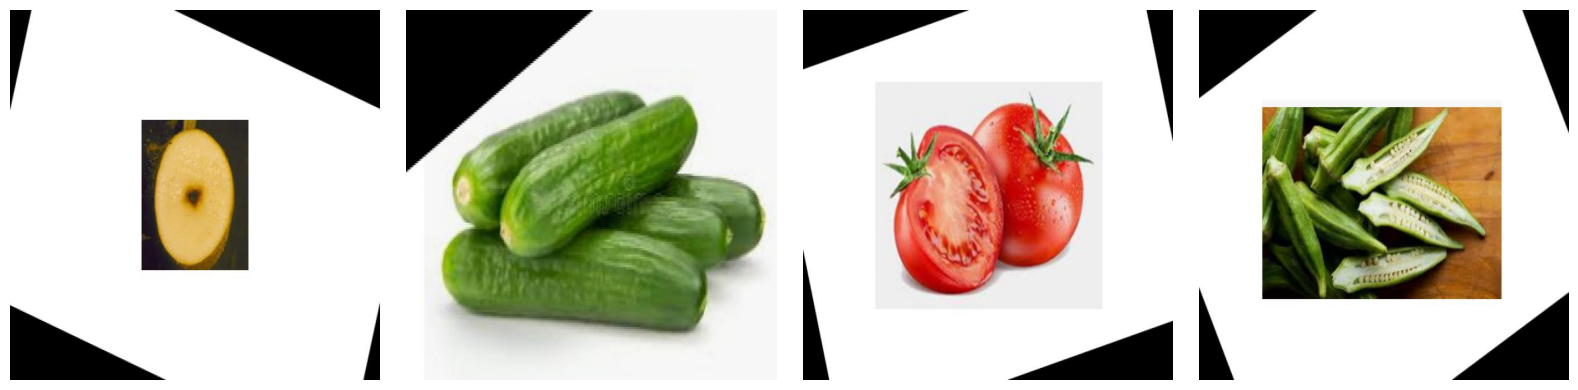

In [16]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

img_dir = "/content/data/detection/train/images"
imgs = os.listdir(img_dir)
print(f"Train images: {len(imgs)}")

# Hiện vài ảnh mẫu
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, fname in zip(axes, random.sample(imgs, 4)):
    ax.imshow(Image.open(os.path.join(img_dir, fname)))
    ax.axis("off")
plt.tight_layout(); plt.show()

In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # nano — nhẹ, phù hợp Colab free

results = model.train(
    data    = "/content/data/detection/data.yaml",
    epochs  = 10,
    imgsz   = 640,
    batch   = 16,
    lr0     = 0.01,
    patience= 10,
    project = "/content/drive/MyDrive/agri_weights",
    name    = "yolov8_defect",
    exist_ok= True,
    device  = 0
)

print(f"✅ Best mAP50: {results.results_dict['metrics/mAP50(B)']:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_defect, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

In [19]:
model = YOLO("/content/drive/MyDrive/agri_weights/yolov8_defect/weights/best.pt")

metrics = model.val(data="/content/data/detection/data.yaml")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision:{metrics.box.mp:.4f}")
print(f"Recall:   {metrics.box.mr:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1168.9±195.6 MB/s, size: 32.9 KB)
val: Scanning /content/data/detection/valid/labels.cache... 1150 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1150/1150 371.0Mit/s 0.0s
val: /content/data/detection/valid/images/1032_jpg.rf.7fa616e0421b0cc241ec608024f90b7d.jpg: 1 duplicate labels removed
val: /content/data/detection/valid/images/1032_jpg.rf.b244afac83d8c8bb1886c9414faceee0.jpg: 1 duplicate labels removed
val: /content/data/detection/valid/images/1032_jpg.rf.d7a2704fee518579e5e1f04c80698d63.jpg: 1 duplicate labels removed
val: /content/data/detection/valid/images/1033_jpg.rf.ef74dae50cb7b641a264ffe12d7b1fd0.jpg: 1 duplicate labels removed
val: /content/data/detection/valid/images/a_r315_png.rf.270549d2958f5e6211c34c3c07f43c03.jpg: 1 duplicate labels removed
val: /content

Test image: /content/data/detection/test/images/b_f453_png.rf.3b8192ee87c5a230361f221f802ec7f7.jpg

image 1/1 /content/data/detection/test/images/b_f453_png.rf.3b8192ee87c5a230361f221f802ec7f7.jpg: 640x640 1 banana, 1 fresh-90-, 7.5ms
Speed: 1.7ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Classes: {0: 'Fresh Oranges', 1: 'PapayaFresh', 2: 'Rotten Oranges', 3: 'Rotten', 4: 'apple', 5: 'bad', 6: 'banana', 7: 'carrot', 8: 'cucumber', 9: 'fresh-20-', 10: 'fresh-70-', 11: 'fresh-90-', 12: 'good', 13: 'okra', 14: 'potato', 15: 'sweet-potato', 16: 'tomato', 17: 'un-usable'}
Số detections: 2
  banana - conf: 0.956
  fresh-90- - conf: 0.919


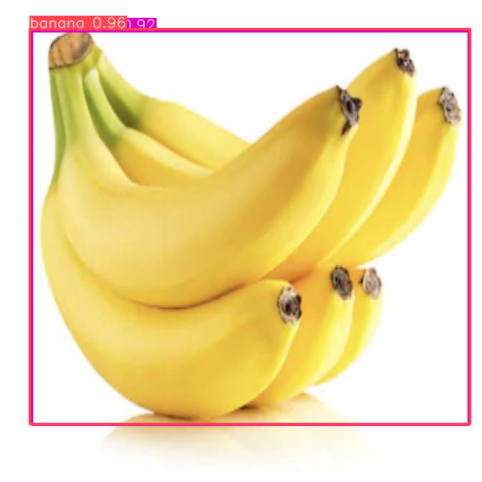

In [27]:
import os, random
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Lấy ảnh từ test set của dataset Roboflow (có label)
test_img_dir = "/content/data/detection/test/images"
imgs = os.listdir(test_img_dir)
test_img = os.path.join(test_img_dir, random.choice(imgs))
print("Test image:", test_img)

results = model(test_img, conf=0.25)[0]
print(f"Classes: {results.names}")
print(f"Số detections: {len(results.boxes)}")
for box in results.boxes:
    print(f"  {results.names[int(box.cls)]} - conf: {float(box.conf):.3f}")

annotated = results.plot()
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
!cat /content/data/detection/data.yaml

names:
- stale tomato
nc: 1
roboflow:
  license: CC BY 4.0
  project: freshness-fruits-and-vegetables
  url: https://universe.roboflow.com/college-74jj5/freshness-fruits-and-vegetables/dataset/1
  version: 1
  workspace: college-74jj5
test: ../test/images
train: ../train/images
val: ../valid/images


Saving 5-loai-rau-cu-chua-day-doc-to-pha-huy-noi-tang-cho-tien-cung-dung-an-nhat-la-loai-so-1-143741.jpg to 5-loai-rau-cu-chua-day-doc-to-pha-huy-noi-tang-cho-tien-cung-dung-an-nhat-la-loai-so-1-143741 (1).jpg

image 1/1 /content/5-loai-rau-cu-chua-day-doc-to-pha-huy-noi-tang-cho-tien-cung-dung-an-nhat-la-loai-so-1-143741 (1).jpg: 352x640 (no detections), 41.5ms
Speed: 2.5ms preprocess, 41.5ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)
Classes: {0: 'Fresh Oranges', 1: 'PapayaFresh', 2: 'Rotten Oranges', 3: 'Rotten', 4: 'apple', 5: 'bad', 6: 'banana', 7: 'carrot', 8: 'cucumber', 9: 'fresh-20-', 10: 'fresh-70-', 11: 'fresh-90-', 12: 'good', 13: 'okra', 14: 'potato', 15: 'sweet-potato', 16: 'tomato', 17: 'un-usable'}
Số detections: 0


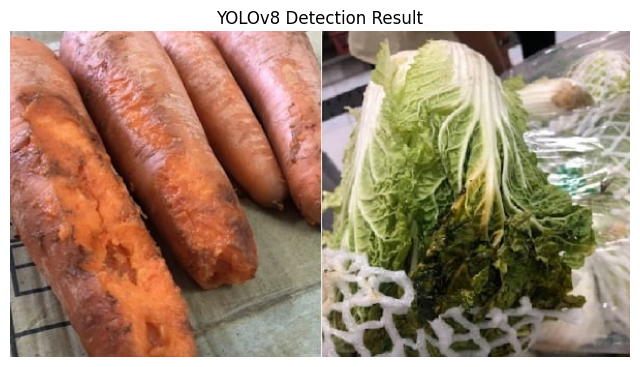

In [23]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Upload ảnh từ máy
uploaded = files.upload()
img_name = list(uploaded.keys())[0]

results = model(img_name, conf=0.25)[0]
print(f"Classes: {results.names}")
print(f"Số detections: {len(results.boxes)}")
for box in results.boxes:
    print(f"  {results.names[int(box.cls)]} - conf: {float(box.conf):.3f}")

annotated = results.plot()
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLOv8 Detection Result")
plt.show()

In [28]:
# Cell cuối — Download weights về máy
from google.colab import files
files.download("/content/drive/MyDrive/agri_weights/efficientnet_best.pth")
files.download("/content/drive/MyDrive/agri_weights/yolov8_defect/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>